In [36]:
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

load_dotenv()

True

In [37]:
model = ChatGroq(model='llama-3.3-70b-versatile')

In [38]:
class SentiSchema(BaseModel):
    sentiment: Literal['Positive','Negative'] = Field(description='Sentiment of the review')
    

In [39]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [40]:
structured_model = model.with_structured_output(SentiSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)


In [41]:
prompt = 'what is the sentiment of the following review: The software is lit'
structured_model.invoke(prompt).sentiment

'Positive'

In [42]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["Positive", "Negative"]
    diagnosis: dict
    response: str

In [43]:
def find_sentiment(state: ReviewState):

    prompt = f'Fpr the following review find out the sentiment \n {state['review']}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

def check_sentimeent(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'Positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState):

    prompt = f'Write a warm Thank You message in response to this review: \n\n {state['review']}\n\n Also, kindly ask the user to leave a feedback on our website'

    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""

    response = model.invoke(prompt).content

    return {'response': response}


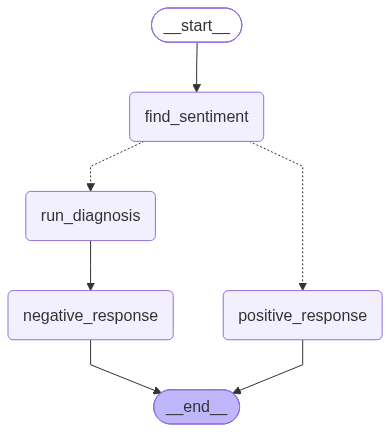

In [44]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('negative_response', negative_response)
graph.add_node('run_diagnosis', run_diagnosis)


graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentimeent)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
workflow

In [45]:
initial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

workflow.invoke(initial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'Negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': "I'm so sorry to hear that you're experiencing a bug issue and that it's causing you frustration. I can imagine how annoying it must be to deal with, and I'm here to help you resolve it as quickly as possible.\n\nI want to assure you that I'm taking your issue very seriously, and I'm committed to finding a solution for you. I understand that you've marked the urgency as high, and I'll do my best to prioritize your case and get back to you with a resolution as soon as possible.\n\nTo help me better understand the issue, could you please provide me with more details about the bug you're experiencing? This will enable me to investigate fu